
Found 123167 files belonging to 2 classes.
Found 30793 files belonging to 2 classes.



Epoch 1/10


3849/3849 [==============================] - 2901s 752ms/step - loss: 0.1450 - accuracy: 0.9424 - val_loss: 0.0405 - val_accuracy: 0.9889
Epoch 2/10
3849/3849 [==============================] - 2876s 745ms/step - loss: 0.0541 - accuracy: 0.9819 - val_loss: 0.0251 - val_accuracy: 0.9928
Epoch 3/10
3849/3849 [==============================] - 2875s 746ms/step - loss: 0.0387 - accuracy: 0.9876 - val_loss: 0.0207 - val_accuracy: 0.9936
Epoch 4/10
3849/3849 [==============================] - 2858s 742ms/step - loss: 0.0307 - accuracy: 0.9902 - val_loss: 0.0153 - val_accuracy: 0.9957
Epoch 5/10
3849/3849 [==============================] - 2837s 736ms/step - loss: 0.0261 - accuracy: 0.9916 - val_loss: 0.0110 - val_accuracy: 0.9967
Epoch 6/10
3849/3849 [==============================] - 2837s 736ms/step - loss: 0.0225 - accuracy: 0.9928 - val_loss: 0.0243 - val_accuracy: 0.9930
Epoch 7/10
3849

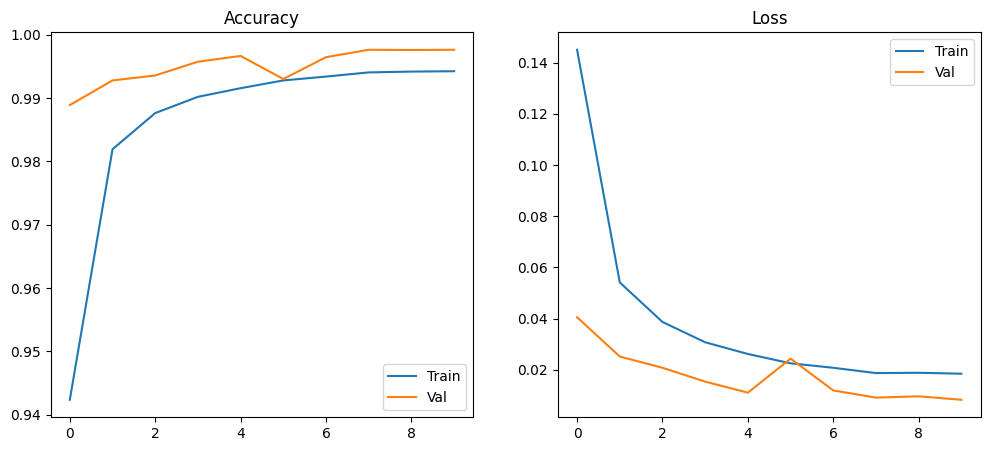

In [1]:

import os
# Comment this line if you have a working GPU stack and want to use GPU:
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Rescaling
import matplotlib.pyplot as plt

# Limit threads to avoid Jupyter kernel instability
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

train_dir = r"F:\Split\train"
val_dir   = r"F:\Split\val"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Datasets
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="binary",
    shuffle=True
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    label_mode="binary",
    shuffle=False
)

# Augmentation pipeline outside the model
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.03),   # ~10°
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

def augment_and_scale(x, y):
    x = data_augmentation(x)
    x = tf.cast(x, tf.float32) / 255.0  # Rescaling
    return x, y

train_data = train_data.map(augment_and_scale, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_data   = val_data.map(lambda x,y: (tf.cast(x, tf.float32)/255.0, y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(train_data, epochs=10, validation_data=val_data)

# Save using the stable Keras format
model.save("drowsiness_cnn_128.keras")

# Plots
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.legend(); plt.title("Loss")
plt.show()
